In [6]:
import geopandas as gpd
import sys
sys.path.insert(0, '..')
# from dgdc.dual_conti import clean_chains, new_angles, merged_G_angle
from dgdc import dual_conti

from pyrosm import OSM, get_data
import osmnx as ox
import momepy

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np
import contextily as ctx

import numpy as np

# create a polygon of the bounding box
from shapely.geometry import box
from shapely.geometry import LineString
from shapely.geometry import Point

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm

from multiprocessing import Pool, cpu_count


# --- Nature-style aesthetics ---
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [2]:
# List of municipalities
municipalities = [
    "Albertslund", "Ballerup", "Brøndby", "Dragør", "Frederiksberg",
    "Furesø", "Gentofte", "Gladsaxe", "Glostrup", "Greve",
    "Herlev", "Hvidovre", "Høje-Taastrup", "Ishøj", "Københavns",
    "Lyngby-Taarbæk", "Rudersdal", "Rødovre", "Tårnby", "Vallensbæk"
]

all_gdfs = []

for name in municipalities:
    try:
        # Fetch municipality polygon
        gdf = ox.geocode_to_gdf(f"{name} Kommune, Denmark")
        all_gdfs.append(gdf)
    except Exception as e:
        print(f"Failed to fetch {name}: {e}")

# Combine all GeoDataFrames
combined_gdf = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True))
combined_polygon = combined_gdf.geometry.union_all()

minx, miny, maxx, maxy = combined_polygon.bounds
bbox_polygon = box(minx, miny, maxx, maxy)
G = ox.graph.graph_from_polygon(bbox_polygon)

In [3]:
gdf_merged, _, _, _ = dual_conti.get_dual_dir_con(t_buffer=100, a_threshold=10, data=G, enforce_degree2=False,simplify_roundabout=True)
gdf_merged.crs = "EPSG:32633" # remove when running. fixed the code

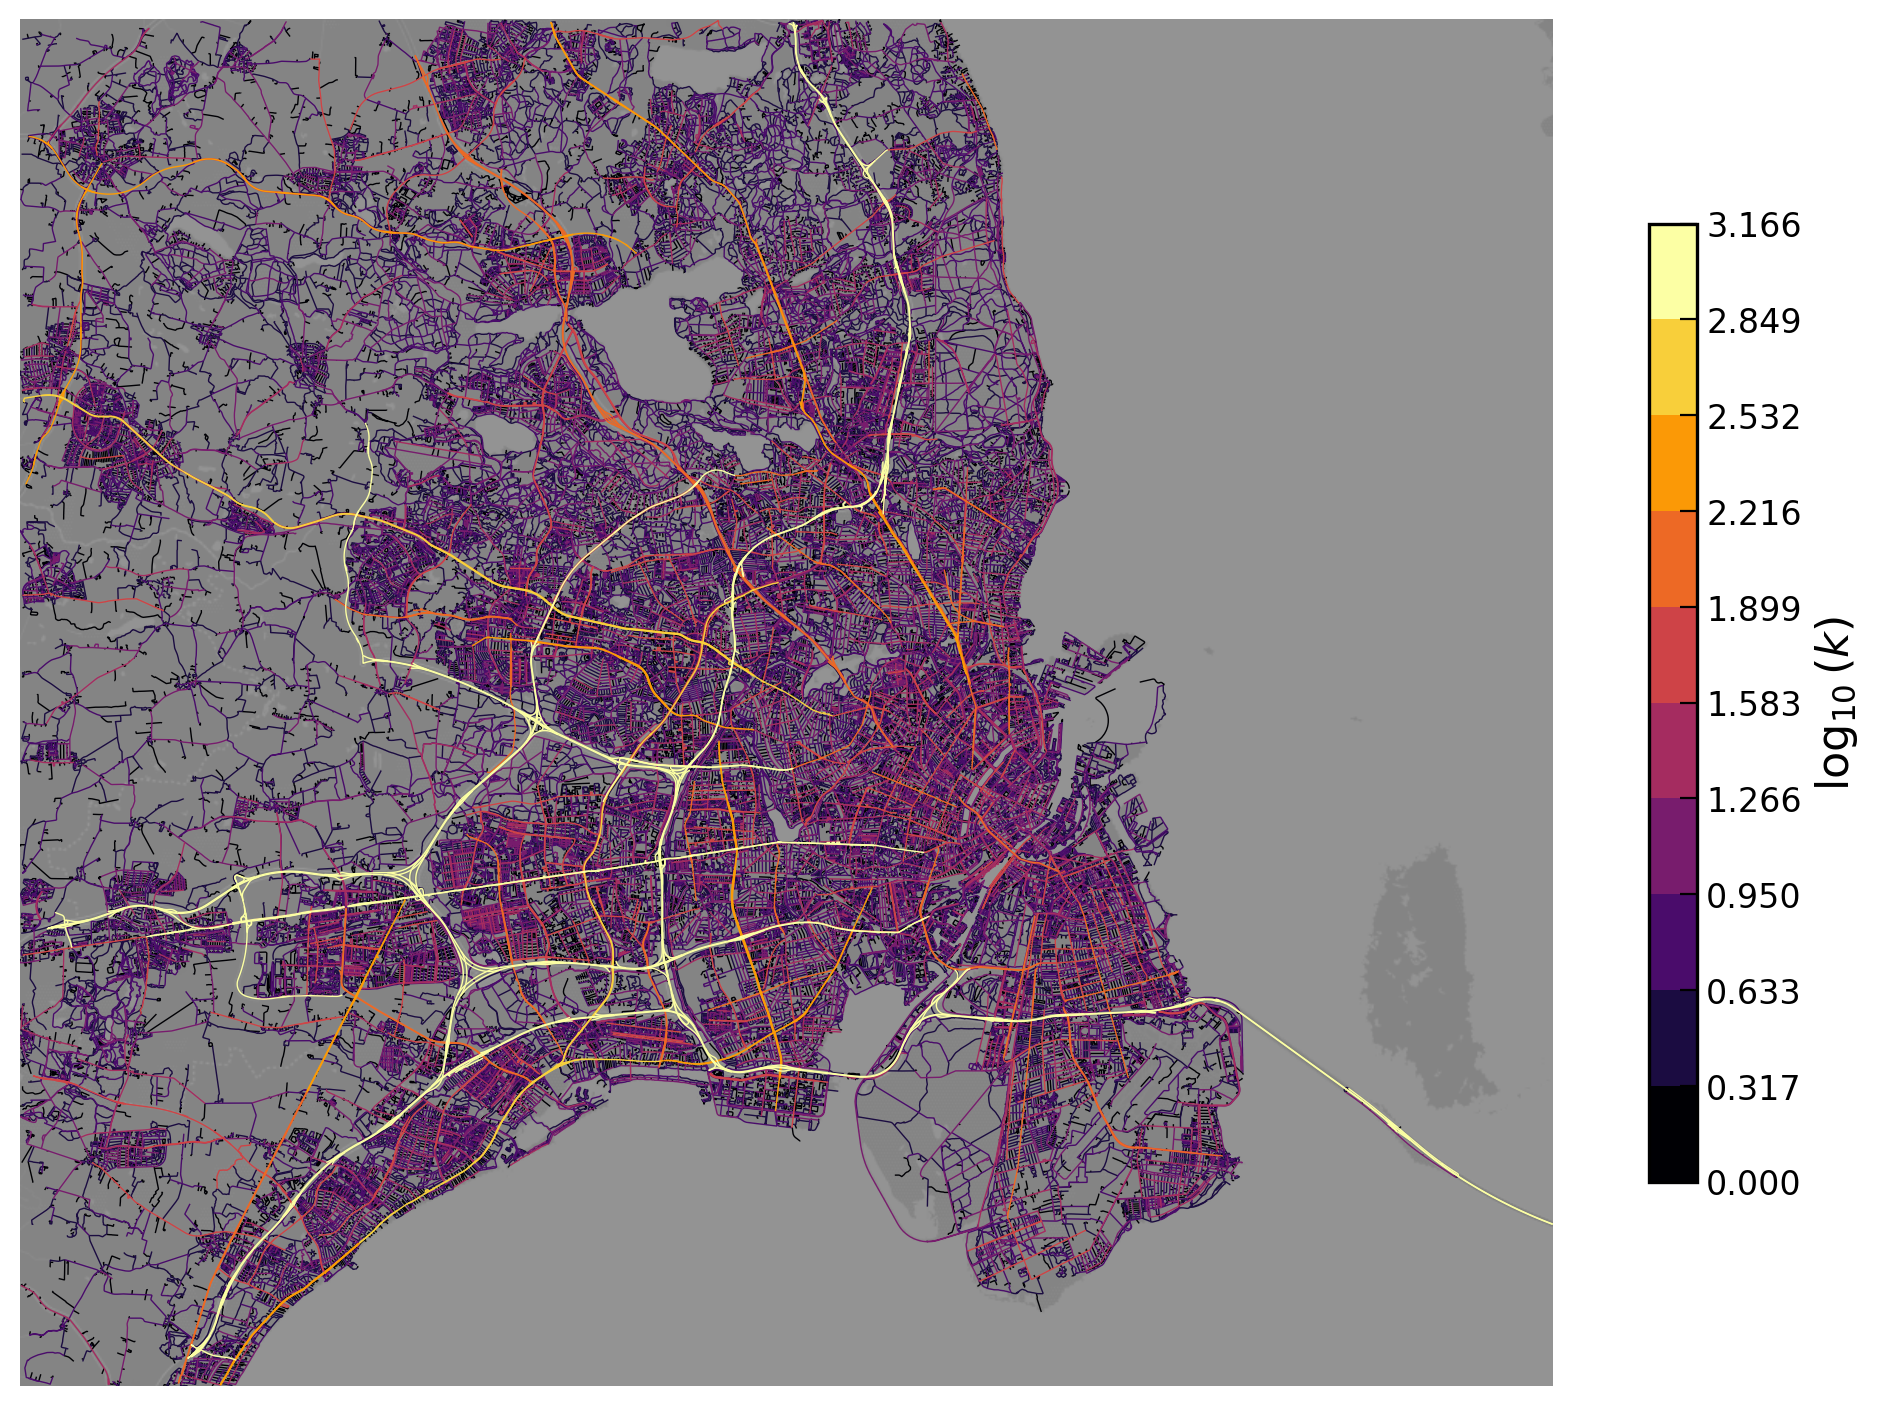

In [4]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)

n_bins = 10
gdf_sorted = gdf_merged.to_crs("EPSG:3857").sort_values('degree_log', ascending=True)
gdf_sorted['degree_bin'] = pd.cut(gdf_sorted['degree_log'], bins=n_bins, labels=False)

cmap = plt.cm.inferno
norm = mcolors.BoundaryNorm(boundaries=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1),ncolors=cmap.N)

for b in range(n_bins):
    subset = gdf_sorted[gdf_sorted['degree_bin'] == b]
    subset.plot(ax=ax, color=cmap(b / (n_bins - 1)), linewidth=0.5)

# Binned colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, spacing='proportional', ticks=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1))

cbar.set_label(r'$\log_{10}(k)$')

# Limit axes to data extent
minx, miny, maxx, maxy = gdf_sorted.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom='auto', attribution=False, alpha=0.5)
# ax.set_title("Greater Copenhagen Road Network", loc='left', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5272/3047145467.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


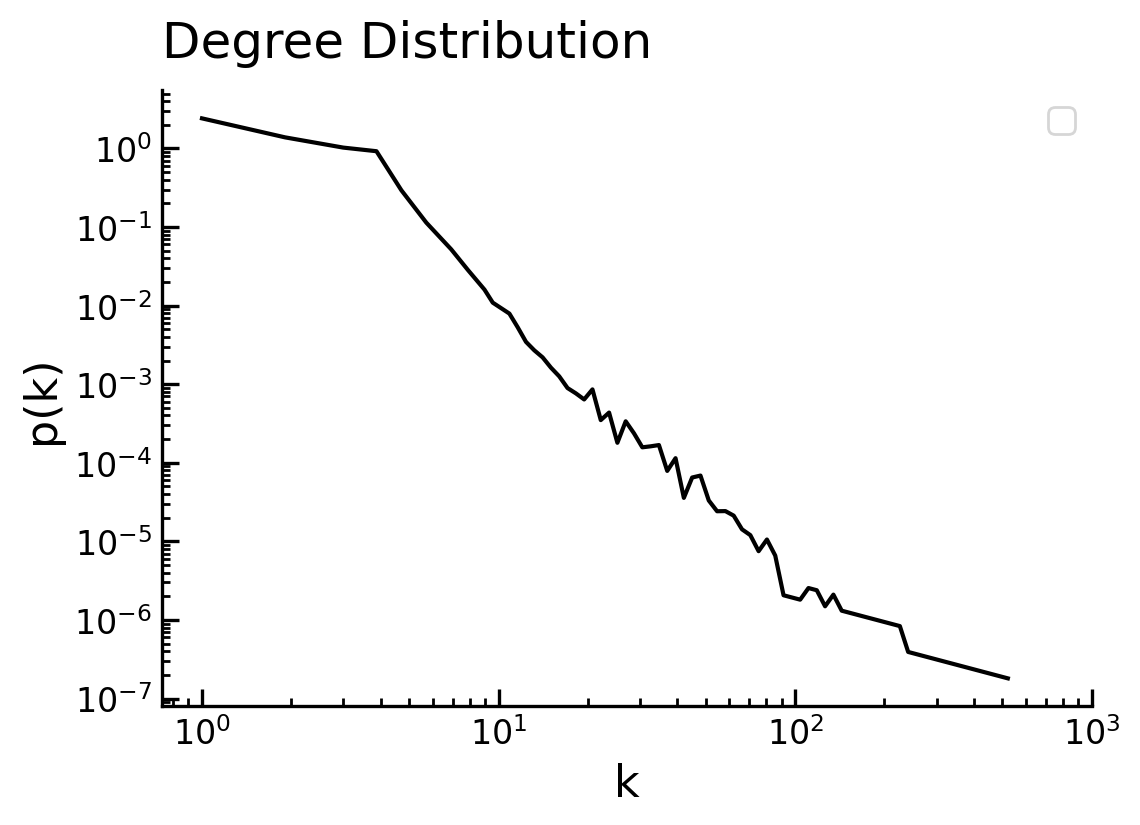

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4),dpi=200)
full = gdf_merged.degree.values
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title("Degree Distribution", loc='left', pad=12)
ax.set_xlabel("k")
ax.set_ylabel("p(k)")

y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')

ax.yaxis.set_minor_formatter(plt.NullFormatter())

# Hide top/right spines (Nature style)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only bottom/left axes
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Major ticks (not too many)
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))

# Minor ticks
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))

# Appearance
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)

# Shade area from "x = 0" (small positive) up to x = 7
# ax.axvspan(xmin=0, xmax=3.99, color='blue', alpha=0.2, zorder=-1)
# ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
# ax.axvspan(xmin=4.01, xmax=1000, color='red', alpha=0.2, zorder=-1)

plt.legend()
ax.set_xlim(right=1000)
plt.show()

In [56]:
# colors = ['#FF8C00', '#00C853']
# colors = ['#FF3D00', '#1DE9B6']
colors=['blue','red']

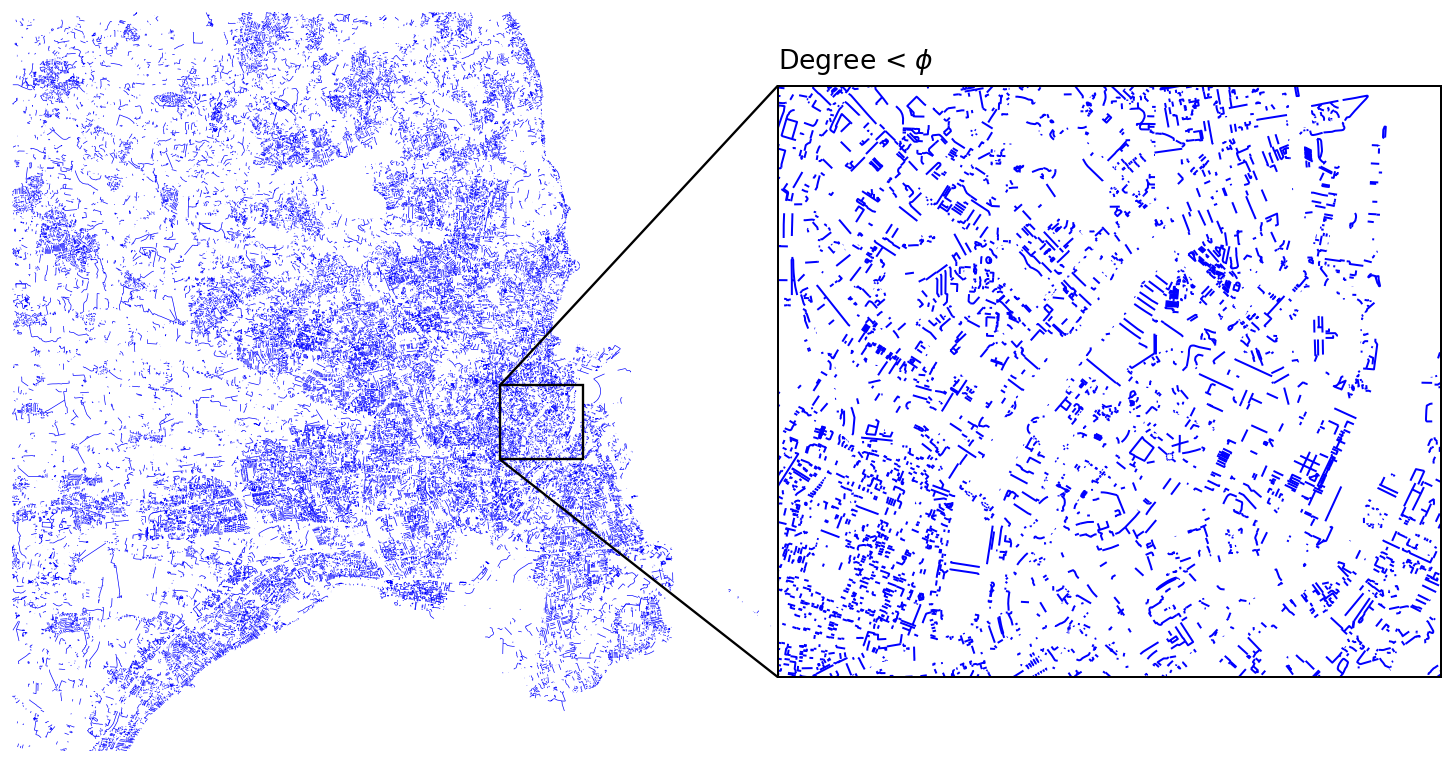

In [57]:
ps = 4

# Compute extent in Web Mercator
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent

# --- Create single subplot ---
fig, ax = plt.subplots(figsize=(15, 8), dpi=120)

# --- Plot only degree < ps ---
gdf_merged[gdf_merged.degree < ps].to_crs(3857).plot(color=colors[0], ax=ax, linewidth=0.4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
# ax.set_title(f"Degree > $\phi$")
ax.axis('off')

# Thicker spines (Nature-like)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# =======================================================================
#                      ★ ZOOM INSET ★
# =======================================================================

# Central 10% zoom region
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10

x1 = x_center - x_range/2
x2 = x_center + x_range/2
y1 = y_center - y_range/2
y2 = y_center + y_range/2

axins = inset_axes(ax, width="80%", height="80%", loc="right", borderpad=-30)
gdf_merged[gdf_merged.degree < ps].to_crs(3857).plot(color=colors[0], ax=axins, linewidth=1.2)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# axins.axis('off')
axins.set_xticks([])
axins.set_yticks([])
axins.set_title(f"Degree < $\phi$",loc='left',fontsize=16)
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="black", lw=1.4,zorder=3)
plt.show()

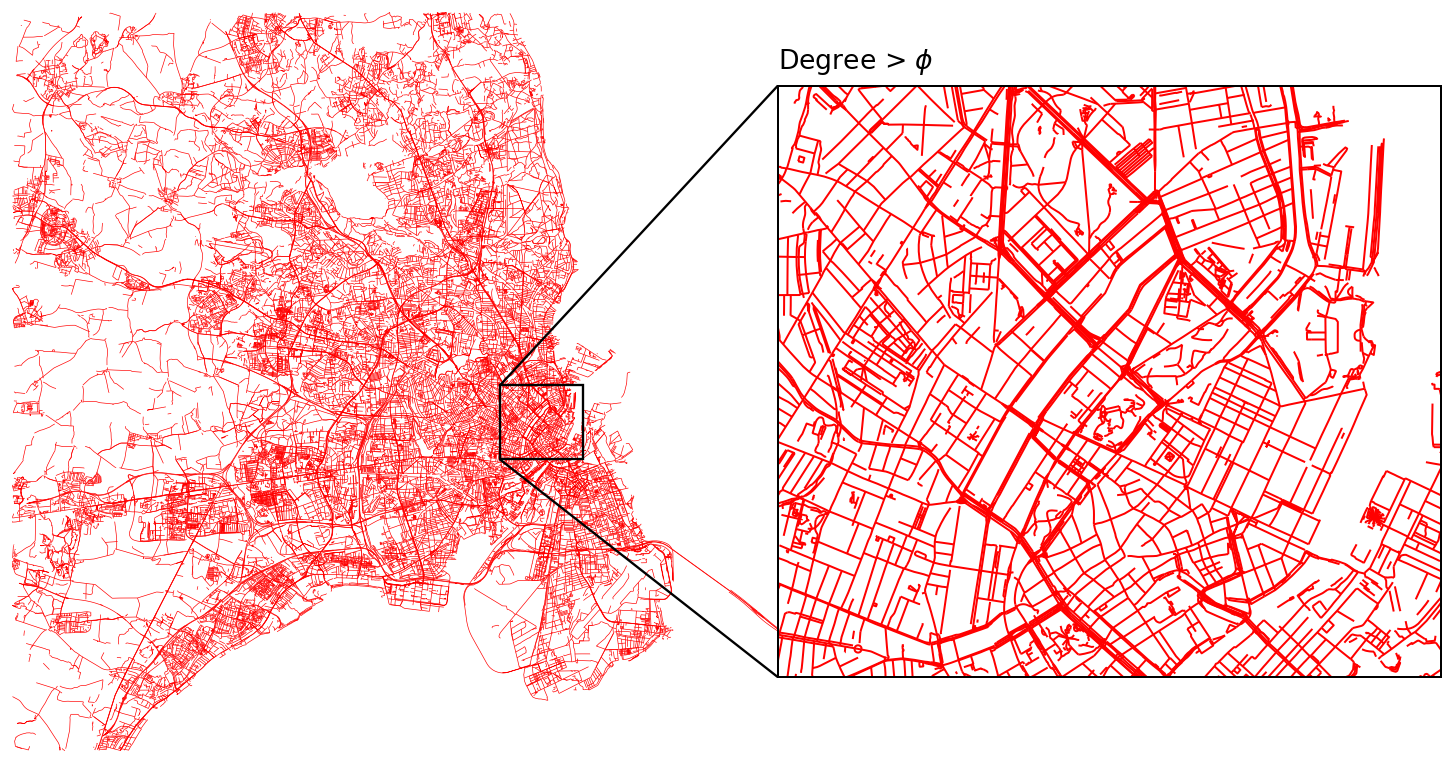

In [58]:
ps = 4

# Compute extent in Web Mercator
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent

# --- Create single subplot ---
fig, ax = plt.subplots(figsize=(15, 8), dpi=120)

# --- Plot only degree < ps ---
gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=ax, linewidth=0.4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
# ax.set_title(f"Degree > $\phi$")
ax.axis('off')

# Thicker spines (Nature-like)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# =======================================================================
#                      ★ ZOOM INSET ★
# =======================================================================

# Central 10% zoom region
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10

x1 = x_center - x_range/2
x2 = x_center + x_range/2
y1 = y_center - y_range/2
y2 = y_center + y_range/2

# Inset axis (bottom-right corner)
axins = inset_axes(ax, width="80%", height="80%", loc="right", borderpad=-30)

gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=axins, linewidth=1.2)

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# axins.axis('off')
axins.set_xticks([])
axins.set_yticks([])
axins.set_title(f"Degree > $\phi$",loc='left',fontsize=16)
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="black", lw=1.4,zorder=3)
plt.show()